<a href="https://colab.research.google.com/github/panguccio/ami-data-analysis/blob/Leticia/epidemiology_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acute Myocadial Infraction Dataset Analysis
Statistical Learning for Epidemiology Project.
## Introduction and Background

In [ ]:
R_environment_file <- "https://drive.usercontent.google.com/download?id=1342zM7G6hRt7bOPf-aOZgIiPkp8vhyyV&export=download&authuser=0&confirm=t&uuid=b3878d6e-a8dc-493d-a015-d3d75d9705f2&at=ALBwUgmhMy9bCrXo6EYce1l2vUjM:1779099976526"
download.file(R_environment_file,
      destfile="./library.tar.gz")
# unzip the compressed R library file: 'library.tar.gz' into the R library folder
untar("library.tar.gz", "library")
# change the R library directory into './library'
.libPaths("library")


In [ ]:
library(readxl)
library(epiR)
library(Epi)
library(popEpi)
library(ggplot2)
library(scales)
library(lubridate)
library(AER)
library(MASS)
library(survival)
library(tidyverse)
library(pmsampsize)
library(psych)
library(corrplot)

Loading required package: survival

Package epiR 2.0.93 is loaded

Type help(epi.about) for summary information

Type browseVignettes(package = 'epiR') to learn how to use epiR for applied epidemiological analyses





Attaching package: ‘popEpi’


The following object is masked from ‘package:survival’:

    Surv



Attaching package: ‘lubridate’


The following object is masked from ‘package:popEpi’:

    is.Date


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading required package: car

Loading required package: carData

Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.2.1     ✔ stringr 1.6.0
✔ forcats 1.0.1     ✔ tibble  3.3.1
✔ purrr   1.2.2     ✔ tidyr   1.3.2
✔ readr   2.2.0  



### Loading and Accessing the Excel File in R

To load an `.xlsx` file in R, we'll use the `readxl` package. First, we need to ensure it's installed and then load the library.

In [ ]:
ami_data <- read_excel('/content/AMI_data.xlsx')
head(ami_data)

day30,sex,age,a65,killip,sho,dia,hyp,hrt,ant,⋯,hei,wei,htn,smk,lip,pan,fam,ste,st4,ttr
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,70.313,1,1,0,0,0,0,1,⋯,177.3,84.0,1,3,1,0,0,1,0,1
0,0,59.844,0,1,0,1,0,0,1,⋯,172.0,115.0,1,1,0,0,1,6,1,0
0,0,59.023,0,1,0,0,0,1,0,⋯,170.0,76.0,1,1,0,0,1,3,0,0
1,1,80.375,1,1,0,0,0,1,0,⋯,154.9,50.0,0,3,0,0,0,3,0,0
0,0,64.750,0,1,0,0,1,0,0,⋯,167.0,97.4,0,1,0,1,1,2,0,1
0,0,53.883,0,1,0,0,0,0,1,⋯,171.0,100.0,1,1,1,0,1,4,0,0


day30    sex    age    a65 killip    sho    dia    hyp    hrt    ant    pmi 
     0      0      0      0      0      0      0      0      0      0      0 
   hei    wei    htn    smk    lip    pan    fam    ste    st4    ttr    BMI 
     0      0      0      0      0      0      0      0      0      0      0

Rows: 3,661
Columns: 22
$ day30  <dbl> 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, …
$ sex    <dbl> 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, …
$ age    <dbl> 70.313, 59.844, 59.023, 80.375, 64.750, 53.883, 48.594, 72.453,…
$ a65    <dbl> 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, …
$ killip <dbl> 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, …
$ sho    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dia    <dbl> 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, …
$ hyp    <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, …
$ hrt    <dbl> 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, …
$ ant    <dbl> 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, …
$ pmi    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, …
$ hei    <dbl> 177.3, 172.0, 170.0, 154.9, 167.0, 171.0, 177.3, 187.0, 197.0, …
$ wei    <dbl> 8

day30,sex,age,a65,killip,sho,dia,hyp,hrt,ant,⋯,wei,htn,smk,lip,pan,fam,ste,st4,ttr,BMI
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,70.313,1,1,0,0,0,0,1,⋯,84.0,1,3,1,0,0,1,0,1,0.4737733
0,0,59.844,0,1,0,1,0,0,1,⋯,115.0,1,1,0,0,1,6,1,0,0.6686047
0,0,59.023,0,1,0,0,0,1,0,⋯,76.0,1,1,0,0,1,3,0,0,0.4470588
1,1,80.375,1,1,0,0,0,1,0,⋯,50.0,0,3,0,0,0,3,0,0,0.3227889
0,0,64.750,0,1,0,0,1,0,0,⋯,97.4,0,1,0,1,1,2,0,1,0.5832335
0,0,53.883,0,1,0,0,0,0,1,⋯,100.0,1,1,1,0,1,4,0,0,0.5847953


tibble [3,661 × 22] (S3: tbl_df/tbl/data.frame)
 $ day30 : num [1:3661] 0 0 0 1 0 0 0 0 0 0 ...
 $ sex   : num [1:3661] 0 0 0 1 0 0 0 0 0 1 ...
 $ age   : num [1:3661] 70.3 59.8 59 80.4 64.8 ...
 $ a65   : num [1:3661] 1 0 0 1 0 0 0 1 1 0 ...
 $ killip: num [1:3661] 1 1 1 1 1 1 1 2 1 1 ...
 $ sho   : num [1:3661] 0 0 0 0 0 0 0 0 0 0 ...
 $ dia   : num [1:3661] 0 1 0 0 0 0 0 0 0 0 ...
 $ hyp   : num [1:3661] 0 0 0 0 1 0 0 0 0 0 ...
 $ hrt   : num [1:3661] 0 0 1 1 0 0 0 0 0 0 ...
 $ ant   : num [1:3661] 1 1 0 0 0 1 0 1 1 0 ...
 $ pmi   : num [1:3661] 0 0 0 0 0 0 0 0 0 0 ...
 $ hei   : num [1:3661] 177 172 170 155 167 ...
 $ wei   : num [1:3661] 84 115 76 50 97.4 100 82 90.9 96.4 61 ...
 $ htn   : num [1:3661] 1 1 1 0 0 1 0 1 1 1 ...
 $ smk   : num [1:3661] 3 1 1 3 1 1 2 2 2 2 ...
 $ lip   : num [1:3661] 1 0 0 0 0 1 0 0 0 1 ...
 $ pan   : num [1:3661] 0 0 0 0 1 0 0 0 0 0 ...
 $ fam   : num [1:3661] 0 1 1 0 1 1 0 1 1 1 ...
 $ ste   : num [1:3661] 1 6 3 3 2 4 3 7 8 3 ...
 $ st4   : num [1:3

     day30             sex              age             a65        
 Min.   :0.0000   Min.   :0.0000   Min.   :23.91   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:51.55   1st Qu.:0.0000  
 Median :0.0000   Median :0.0000   Median :61.27   Median :0.0000  
 Mean   :0.0631   Mean   :0.2568   Mean   :60.85   Mean   :0.3944  
 3rd Qu.:0.0000   3rd Qu.:1.0000   3rd Qu.:70.09   3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :1.0000   Max.   :89.48   Max.   :1.0000  
     killip           sho               dia              hyp         
 Min.   :1.000   Min.   :0.00000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:1.000   1st Qu.:0.00000   1st Qu.:0.0000   1st Qu.:0.00000  
 Median :1.000   Median :0.00000   Median :0.0000   Median :0.00000  
 Mean   :1.157   Mean   :0.01694   Mean   :0.1314   Mean   :0.08713  
 3rd Qu.:1.000   3rd Qu.:0.00000   3rd Qu.:0.0000   3rd Qu.:0.00000  
 Max.   :4.000   Max.   :1.00000   Max.   :1.0000   Max.   :1.00000  
      hrt              ant        

Warning message in polychoric(data[, p], smooth = smooth, global = global, weight = weight, :
“The items do not have an equal number of response alternatives, global set to FALSE.”


Warning message in biserialc(x[, j], y[, i], j, i):
“For x = 1 y = 3 x seems to be dichotomous, not continuous”
Warning message in biserialc(x[, j], y[, i], j, i):
“For x = 4 y = 14 x seems to be dichotomous, not continuous”


Warning message in polydi(data[, p, drop = FALSE], data[, d, drop = FALSE], global = global, :
“The items do not have an equal number of response alternatives, I am setting global to FALSE”


       day30   sex   age   a65 killip   sho   dia   hyp   hrt   ant   pmi   hei
day30   1.00  0.20  0.44  0.45   0.45  0.60  0.10  0.27  0.26  0.26  0.23 -0.19
sex     0.20  1.00  0.33  0.38   0.07 -0.04  0.09  0.14  0.09 -0.01 -0.09 -0.93
age     0.44  0.33  1.00  1.00   0.23  0.21  0.05  0.02 -0.05  0.06  0.15 -0.24
a65     0.45  0.38  1.00  1.00   0.26  0.25  0.03 -0.03 -0.02  0.08  0.16 -0.29
killip  0.45  0.07  0.23  0.26   1.00  0.98  0.07  0.12  0.25  0.20  0.18 -0.13
sho     0.60 -0.04  0.21  0.25   0.98  1.00  0.17  0.23  0.40  0.36  0.15 -0.05
dia     0.10  0.09  0.05  0.03   0.07  0.17  1.00  0.06  0.18  0.09  0.15 -0.08
hyp     0.27  0.14  0.02 -0.03   0.12  0.23  0.06  1.00 -0.19 -0.13 -0.01 -0.05
hrt     0.26  0.09 -0.05 -0.02   0.25  0.40  0.18 -0.19  1.00  0.22  0.06 -0.05
ant     0.26 -0.01  0.06  0.08   0.20  0.36  0.09 -0.13  0.22  1.00 -0.05  0.00
pmi     0.23 -0.09  0.15  0.16   0.18  0.15  0.15 -0.01  0.06 -0.05  1.00  0.00
hei    -0.19 -0.93 -0.24 -0.29  -0.13 -0

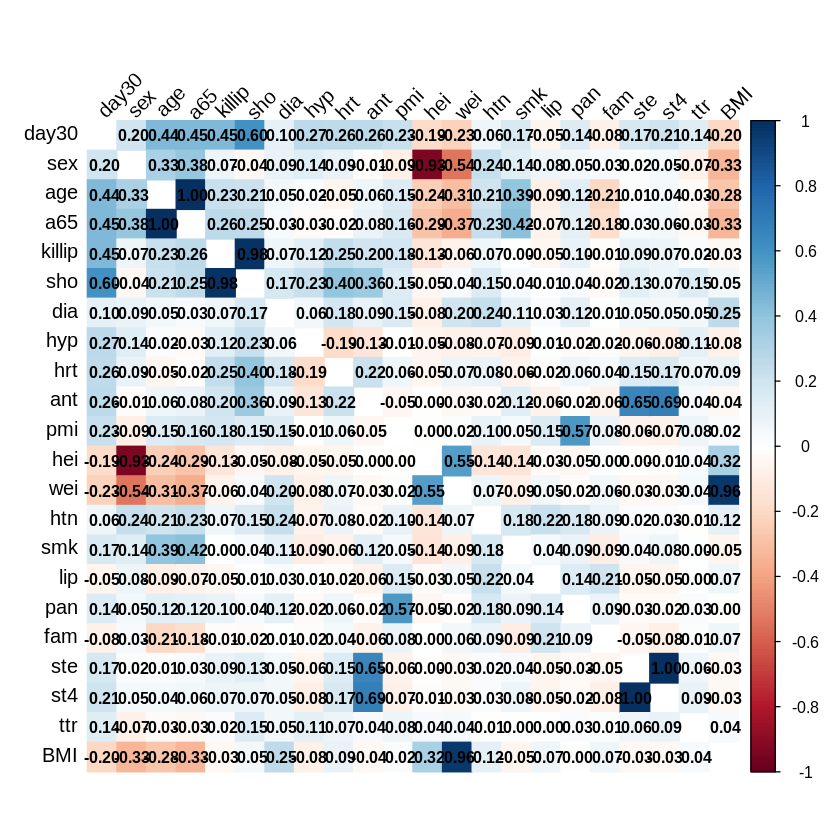

In [ ]:
#DESCRIPTIVE ANALYSIS
ami_data$BMI <- ami_data$wei/ami_data$hei

#checking for missing values
colSums(is.na(ami_data)) # there are no missing values in the data

glimpse(ami_data) # the data contains 3661 observation
head(ami_data)
str(ami_data) # all variables are numerical.

summary(ami_data)

#correlation table or graph
Cor1<- mixedCor(ami_data)
cor_matrix <- Cor1$rho
print(round(cor_matrix, 2))

corrplot(cor_matrix,
         method = "color",
         type = "full",
         addCoef.col = "black",
         number.cex = 0.8,
         tl.col = "black",
         tl.srt = 45,
         diag = FALSE)